# Monsoon Onset & Soil Moisture Pick-up — 2025

Investigate how ERA5 surface soil moisture responds to the monsoon onset detected from IMD 1° rainfall.

**Workflow:**
1. Download ERA5 *volumetric soil water layer 1* (0–7 cm) via the CDS API
2. Load and regrid to the IMD 1° grid
3. Load the 2025 onset dates
4. Extract soil moisture time-series centred on each grid point's onset date
5. Visualise and quantify the soil moisture step change at onset

## 1. Import Required Libraries

In [20]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath(".."))

import yaml
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as mgridspec
from matplotlib.colors import BoundaryNorm
from scipy import stats

# ARCO-ERA5 access — install with:  pip install gcsfs zarr
try:
    import gcsfs, zarr
    print("gcsfs & zarr available ✓")
except ImportError:
    print("Missing packages — run:  pip install gcsfs zarr")

# Package utilities
import monsoon_onset.detector as _det
import monsoon_onset.loader   as _ldr
import monsoon_onset.plotter  as _plt
importlib.reload(_det); importlib.reload(_ldr); importlib.reload(_plt)

from monsoon_onset.loader   import load_rainfall
from monsoon_onset.detector import detect_onset
from monsoon_onset.plotter  import get_india_outline, doy_to_date_string

%matplotlib inline
os.makedirs("../output", exist_ok=True)
print("All imports OK")


gcsfs & zarr available ✓
All imports OK


## 2. Download ERA5 Soil Moisture from ARCO-ERA5

[ARCO-ERA5](https://github.com/google-research/arco-era5) is a **free, Analysis-Ready, Cloud-Optimized** copy of the full ERA5 archive hosted on Google Cloud Storage as a Zarr store.  
No CDS account or API key is needed — just an internet connection.

**Requirements** (install once):
```
pip install gcsfs zarr
```

The variable we want is **`volumetric_soil_water_layer_1`** (`swvl1`, 0–7 cm).  
We subset to the India domain and April–September 2025, then save a local NetCDF cache so subsequent runs skip the download.

In [2]:
import gcsfs
import zarr

YEAR    = 2025
SM_FILE = f"../data/era5_swvl1_{YEAR}.nc"   # local cache path

# India domain bounding box
LAT_SLICE = slice(38, 5)    # ARCO ERA5 latitude is stored N→S
LON_SLICE = slice(65, 100)

# Date range
TIME_START = f"{YEAR}-04-01"
TIME_END   = f"{YEAR}-09-30"

if os.path.exists(SM_FILE):
    print(f"Cache found: {SM_FILE}  →  skipping download")
else:
    os.makedirs("../data", exist_ok=True)
    print("Opening ARCO-ERA5 Zarr store (anonymous)…")

    # ── Open the ARCO-ERA5 single-level store ─────────────────────────────────
    fs   = gcsfs.GCSFileSystem(token="anon")
    store = fs.get_mapper("gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3")
    ds_arco = xr.open_zarr(store, consolidated=True, chunks={})

    print("Available variables (subset):", [v for v in ds_arco.data_vars if "soil" in v.lower() or "swvl" in v.lower()])

    # ── Select swvl1 and subset spatially + temporally ────────────────────────
    sm_arco = (
        ds_arco["volumetric_soil_water_layer_1"]
        .sel(
            latitude=LAT_SLICE,
            longitude=LON_SLICE,
            time=slice(TIME_START, TIME_END),
        )
        # Resample to daily (take midday value — hour 12)
        .resample(time="1D").mean()
    )

    print("Fetching data from GCS (this may take a few minutes)…")
    sm_arco = sm_arco.compute()   # pull into memory

    # ── Save to NetCDF cache ──────────────────────────────────────────────────
    sm_arco.to_netcdf(SM_FILE)
    print(f"Saved → {SM_FILE}")
    print(f"Shape  : {sm_arco.shape}")
    print(f"Time   : {str(sm_arco.time.values[0])[:10]} → {str(sm_arco.time.values[-1])[:10]}")


Opening ARCO-ERA5 Zarr store (anonymous)…
Available variables (subset): ['soil_temperature_level_1', 'soil_temperature_level_2', 'soil_temperature_level_3', 'soil_temperature_level_4', 'soil_type', 'volumetric_soil_water_layer_1', 'volumetric_soil_water_layer_2', 'volumetric_soil_water_layer_3', 'volumetric_soil_water_layer_4']
Fetching data from GCS (this may take a few minutes)…
Saved → ../data/era5_swvl1_2025.nc
Shape  : (183, 133, 141)
Time   : 2025-04-01 → 2025-09-30


## 3. Load and Preprocess ERA5 Soil Moisture

- Rename dimensions to `lat` / `lon` for consistency
- ERA5 `swvl1` is in **m³ m⁻³** (volumetric, 0–1), no unit conversion needed
- **Regrid using CDO `remapcon`** (conservative remapping) onto the IMD 1° grid — more accurate than bilinear for flux-like variables like soil moisture

In [18]:
import subprocess

# ── Load config ───────────────────────────────────────────────────────────────
with open("../configs/imd_1deg.yaml") as f:
    cfg = yaml.safe_load(f)
dataset_cfg = cfg["dataset"]
onset_cfg   = cfg["onset"]
shp_path    = dataset_cfg.get("shapefile")

# ── Paths ─────────────────────────────────────────────────────────────────────
imd_file    = os.path.join(dataset_cfg["data_folder"],
                           dataset_cfg["file_pattern"].format(year=YEAR))
sm_remap_file = SM_FILE.replace(".nc", "_remapcon_imd1deg.nc")

# ── CDO remapcon: conservative regrid ERA5 SM → IMD 1° grid ──────────────────
if os.path.exists(sm_remap_file):
    print(f"Remapped cache found: {sm_remap_file}  →  skipping CDO")
else:
    print(f"Target grid (IMD 1°) : {imd_file}")
    print(f"Source file          : {SM_FILE}")
    print(f"Output file          : {sm_remap_file}")
    print("Running CDO remapcon …")
    cmd = ["cdo", "-s", f"remapcon,{imd_file}", SM_FILE, sm_remap_file]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("CDO stderr:\n", result.stderr)
        raise RuntimeError("CDO remapcon failed — see stderr above")
    print(f"Done ✓  →  {sm_remap_file}")

# ── Load the remapped file ────────────────────────────────────────────────────
sm_ds = xr.open_dataset(sm_remap_file)
print(sm_ds)

sm_var = [v for v in sm_ds.data_vars if "swvl" in v.lower() or "soil" in v.lower()][0]
print(f"\nSoil-moisture variable: {sm_var}")
sm_imd = sm_ds[sm_var]

# Standardise dimension names → always produce 'lat' and 'lon'
_LAT_NAMES = {"latitude", "lat", "LATITUDE", "LAT", "nav_lat"}
_LON_NAMES = {"longitude", "lon", "LONGITUDE", "LON", "nav_lon"}
rename = {}
for d in sm_imd.dims:
    if d in _LAT_NAMES and d != "lat":
        rename[d] = "lat"
    if d in _LON_NAMES and d != "lon":
        rename[d] = "lon"
if rename:
    sm_imd = sm_imd.rename(rename)
    print(f"Renamed dims: {rename}")

sm_imd["time"] = pd.to_datetime(sm_imd.time.values)
sm_imd.name = "swvl1"
sm_imd.attrs["units"] = "m3 m-3"
sm_imd.attrs["long_name"] = "Volumetric soil water layer 1 (0-7 cm) — CDO remapcon → IMD 1°"

# ── Get target grid from the remapped data ────────────────────────────────────
target_lat = sm_imd.lat.values
target_lon = sm_imd.lon.values

# ── Load IMD rainfall (needed later) ─────────────────────────────────────────
rainfall_da = load_rainfall(YEAR, dataset_cfg)

print(f"\nRemapped shape  : {sm_imd.shape}")
print(f"Target grid     : {len(target_lat)} lats × {len(target_lon)} lons")
print(f"Lat range       : {float(sm_imd.lat.min()):.2f} – {float(sm_imd.lat.max()):.2f}")
print(f"Lon range       : {float(sm_imd.lon.min()):.2f} – {float(sm_imd.lon.max()):.2f}")
print(f"SM range        : {float(sm_imd.min()):.4f} – {float(sm_imd.max()):.4f}  m³/m³")
sm_imd


Remapped cache found: ../data/era5_swvl1_2025_remapcon_imd1deg.nc  →  skipping CDO
<xarray.Dataset> Size: 847kB
Dimensions:                        (time: 183, LATITUDE: 33, LONGITUDE: 35)
Coordinates:
  * time                           (time) datetime64[ns] 1kB 2025-04-01 ... 2...
  * LONGITUDE                      (LONGITUDE) float64 280B 66.5 67.5 ... 100.5
  * LATITUDE                       (LATITUDE) float64 264B 6.5 7.5 ... 37.5 38.5
Data variables:
    volumetric_soil_water_layer_1  (time, LATITUDE, LONGITUDE) float32 845kB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Thu May 14 00:13:19 2026: cdo -s remapcon,/Users/Rajat/Libr...
    CDO:          Climate Data Operators version 2.5.0 (https://mpimet.mpg.de...

Soil-moisture variable: volumetric_soil_water_layer_1
Renamed dims: {'LATITUDE': 'lat', 'LONGITUDE': 'lon'}
Loading 2025 rainfall from: /Users/Rajat/Library/CloudStorage/OneDrive-

<xarray.DataArray 'swvl1' (time: 183, lat: 33, lon: 35)> Size: 845kB
array([[[-1.080334e-07, -1.080334e-07, ...,  3.060634e-02,  1.258068e-01],
        [-1.080334e-07, -1.080334e-07, ...,  2.172439e-01,  3.412006e-01],
        ...,
        [ 1.716290e-01,  1.958296e-01, ...,  3.014499e-01,  2.453100e-01],
        [ 2.835325e-01,  2.838431e-01, ...,  3.522160e-01,  3.516983e-01]],

       [[-1.825392e-07, -1.825392e-07, ...,  3.564272e-02,  1.419474e-01],
        [-1.825392e-07, -1.825392e-07, ...,  2.508686e-01,  4.255238e-01],
        ...,
        [ 1.429416e-01,  1.729312e-01, ...,  3.000894e-01,  2.449763e-01],
        [ 2.691559e-01,  2.671421e-01, ...,  3.518533e-01,  3.514211e-01]],

       ...,

       [[ 6.373972e-06,  6.373972e-06, ...,  5.279936e-02,  1.796686e-01],
        [ 6.373972e-06,  6.373972e-06, ...,  3.273605e-01,  4.699573e-01],
        ...,
        [ 7.487904e-02,  9.973643e-02, ...,  2.964682e-01,  2.763912e-01],
        [ 1.272314e-01,  1.160648e-01, ...,  3.473899e-01,  3.677543e-01]],

       [[-2.744297e-07, -2.744297e-07, ...,  4.950958e-02,  1.703627e-01],
        [-2.744297e-07, -2.744297e-07, ...,  3.129510e-01,  4.416348e-01],
        ...,
        [ 7.391349e-02,  9.843095e-02, ...,  2.897996e-01,  2.697315e-01],
        [ 1.248906e-01,  1.133764e-01, ...,  3.417542e-01,  3.630550e-01]]],
      shape=(183, 33, 35), dtype=float32)
Coordinates:
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * time     (time) datetime64[ns] 1kB 2025-04-01 2025-04-02 ... 2025-09-30
Attributes:
    long_name:   Volumetric soil water layer 1 (0-7 cm) — CDO remapcon → IMD 1°
    units:       m3 m-3
    short_name:  swvl1

## 4. Compute / Load Monsoon Onset Dates for 2025

Run the same IMD-based onset detection as in `onset_imd_2025.ipynb`.  
If you have already saved `onset_da` to a NetCDF you can load it instead to save time.

In [21]:
import xarray as xr

thresh_ds  = xr.open_dataset(dataset_cfg["threshold_file"])
thresh_da  = thresh_ds[dataset_cfg.get("threshold_var", "MWmean")]

onset_da = detect_onset(
    rainfall_da=rainfall_da,
    threshold_da=thresh_da,
    year=YEAR,
    cfg=onset_cfg,
)

# DOY version for convenience
onset_doy = xr.where(onset_da.notnull(),
                     onset_da.dt.dayofyear.astype(float), np.nan)

valid = int(onset_doy.notnull().sum())
total = int(onset_doy.size)
print(f"Valid onsets : {valid} / {total}")
print(f"Earliest     : {doy_to_date_string(float(onset_doy.min()))}")
print(f"Latest       : {doy_to_date_string(float(onset_doy.max()))}")
onset_da


Onset detection start: 2025-04-01
  Valid onsets: 326/1155 (28.2%)
Valid onsets : 326 / 1155
Earliest     : 04/01
Latest       : 11/07


<xarray.DataArray 'onset_date' (lat: 33, lon: 35)> Size: 9kB
array([['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ...,
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT'],
       ['NaT', 'NaT', 'NaT', ..., 'NaT', 'NaT', 'NaT']],
      shape=(33, 35), dtype='datetime64[ns]')
Coordinates:
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    description:           Onset date with dry-spell veto
    start_date:            2025-04-01
    wet_spell_window:      5
    dry_spell_window:      10
    dry_spell_threshold:   5
    dry_spell_check_days:  30
    mok_filter:            False

## 5. Extract Soil Moisture Time-series Centred on Onset

For each grid point with a valid onset date, extract the soil moisture for a **±30-day window** around the onset date.  
This builds a `[lat, lon, lag]` array where `lag=0` is the onset day.

In [6]:
HALF_WIN = 30   # days before and after onset
lags     = np.arange(-HALF_WIN, HALF_WIN + 1)   # -30 … +30

sm_vals  = sm_imd.values          # [time, lat, lon]
time_idx = pd.DatetimeIndex(sm_imd.time.values)

n_lat = len(target_lat)
n_lon = len(target_lon)
n_lag = len(lags)

# Output array: [lag, lat, lon]
sm_centred = np.full((n_lag, n_lat, n_lon), np.nan)

for i, lat_v in enumerate(target_lat):
    for j, lon_v in enumerate(target_lon):
        onset_ts = onset_da.sel(lat=lat_v, lon=lon_v).values
        if pd.isna(onset_ts):
            continue
        onset_date = pd.Timestamp(onset_ts)

        for k, lag in enumerate(lags):
            tgt_date = onset_date + pd.Timedelta(days=int(lag))
            if tgt_date in time_idx:
                t_pos = time_idx.get_loc(tgt_date)
                sm_centred[k, i, j] = sm_vals[t_pos, i, j]

sm_centred_da = xr.DataArray(
    sm_centred,
    dims=["lag", "lat", "lon"],
    coords={"lag": lags, "lat": target_lat, "lon": target_lon},
    name="swvl1_onset_centred",
    attrs={"units": "m3 m-3",
           "description": f"Soil moisture ±{HALF_WIN} days around onset (lag=0 = onset day)"},
)

valid_pts = int(np.isfinite(sm_centred[HALF_WIN]).sum())   # lag=0 slice
print(f"Grid points with data at onset (lag=0): {valid_pts}")
sm_centred_da


Grid points with data at onset (lag=0): 325


<xarray.DataArray 'swvl1_onset_centred' (lag: 61, lat: 33, lon: 35)> Size: 564kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(61, 33, 35))
Coordinates:
  * lag      (lag) int64 488B -30 -29 -28 -27 -26 -25 -24 ... 25 26 27 28 29 30
  * lat      (lat) float64 264B 6.5 7.5 8.5 9.5 10.5 ... 35.5 36.5 37.5 38.5
  * lon      (lon) float64 280B 66.5 67.5 68.5 69.5 ... 97.5 98.5 99.5 100.5
Attributes:
    units:        m3 m-3
    description:  Soil moisture ±30 days around onset (lag=0 = onset day)

## 6. Align Onset Dates & Compute Soil Moisture Anomaly

Define the **pre-onset baseline** as the mean soil moisture over days −30 to −5 (avoiding the transition zone), then compute the anomaly at each lag relative to this baseline.  
This highlights how much wetter the soil gets after onset at each grid point.

In [12]:
BASELINE_LAGS = slice(-30, -5)   # lag indices for pre-onset baseline

# Baseline: mean over lag = -30 … -5 at each grid point
baseline = sm_centred_da.sel(lag=BASELINE_LAGS).mean(dim="lag")

# Anomaly = centred SM - baseline
sm_anom = sm_centred_da - baseline
sm_anom.name = "swvl1_anomaly"
sm_anom.attrs.update({"units": "m3 m-3",
                       "description": "SM anomaly relative to pre-onset mean (lag -30 to -5)"})

# ── Domain-mean SM profiles ───────────────────────────────────────────────────
sm_mean   = sm_centred_da.mean(dim=["lat", "lon"])
sm_p25    = sm_centred_da.quantile(0.25, dim=["lat", "lon"])
sm_p75    = sm_centred_da.quantile(0.75, dim=["lat", "lon"])

anom_mean = sm_anom.mean(dim=["lat", "lon"])
anom_p25  = sm_anom.quantile(0.25, dim=["lat", "lon"])
anom_p75  = sm_anom.quantile(0.75, dim=["lat", "lon"])

# ── Rainfall centred on onset (same lag window) ───────────────────────────────
rain_vals  = rainfall_da.values          # [time, lat, lon]
rain_times = pd.DatetimeIndex(rainfall_da.time.values)

rain_centred = np.full((n_lag, n_lat, n_lon), np.nan)

for i, lat_v in enumerate(target_lat):
    for j, lon_v in enumerate(target_lon):
        onset_ts_ij = onset_da.sel(lat=lat_v, lon=lon_v).values
        if pd.isna(onset_ts_ij):
            continue
        onset_date_ij = pd.Timestamp(onset_ts_ij)
        for k, lag in enumerate(lags):
            tgt = onset_date_ij + pd.Timedelta(days=int(lag))
            if tgt in rain_times:
                rain_centred[k, i, j] = rain_vals[rain_times.get_loc(tgt), i, j]

rain_centred_da = xr.DataArray(
    rain_centred,
    dims=["lag", "lat", "lon"],
    coords={"lag": lags, "lat": target_lat, "lon": target_lon},
    name="rain_onset_centred",
    attrs={"units": "mm/day", "description": f"Rainfall ±{HALF_WIN} days around onset"},
)

rain_mean = rain_centred_da.mean(dim=["lat", "lon"])
rain_p25  = rain_centred_da.quantile(0.25, dim=["lat", "lon"])
rain_p75  = rain_centred_da.quantile(0.75, dim=["lat", "lon"])

print("Baseline SM (mean over domain) :", float(baseline.mean()))
print("SM at onset (lag=0) [mean]      :", float(sm_centred_da.sel(lag=0).mean()))
print("Anomaly at lag=+7 [mean]        :", float(sm_anom.sel(lag=7).mean()))
print("Rain at onset (lag=0) [mean]    :", float(rain_centred_da.sel(lag=0).mean(skipna=True)))


Baseline SM (mean over domain) : 0.22882093465739056
SM at onset (lag=0) [mean]      : 0.28689976575468
Anomaly at lag=+7 [mean]        : 0.10801301068959357
Rain at onset (lag=0) [mean]    : 15.444823922920811


## 7. Visualise Soil Moisture Pick-up Around Onset

Four panels:
1. **Domain-mean SM time-series** centred on onset (raw + IQR shading)
2. **Domain-mean SM anomaly** centred on onset
3. **Spatial map** of SM at onset (lag = 0)
4. **Spatial map** of SM anomaly at lag = +7 days (one week after onset)

Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp
Loaded India outline from: /Users/Rajat/Library/CloudStorage/OneDrive-TheUniversityofChicago/documents/conferences/icts_monsoon_26/mr_onset/data/ind_map_shpfile/india_shapefile.shp


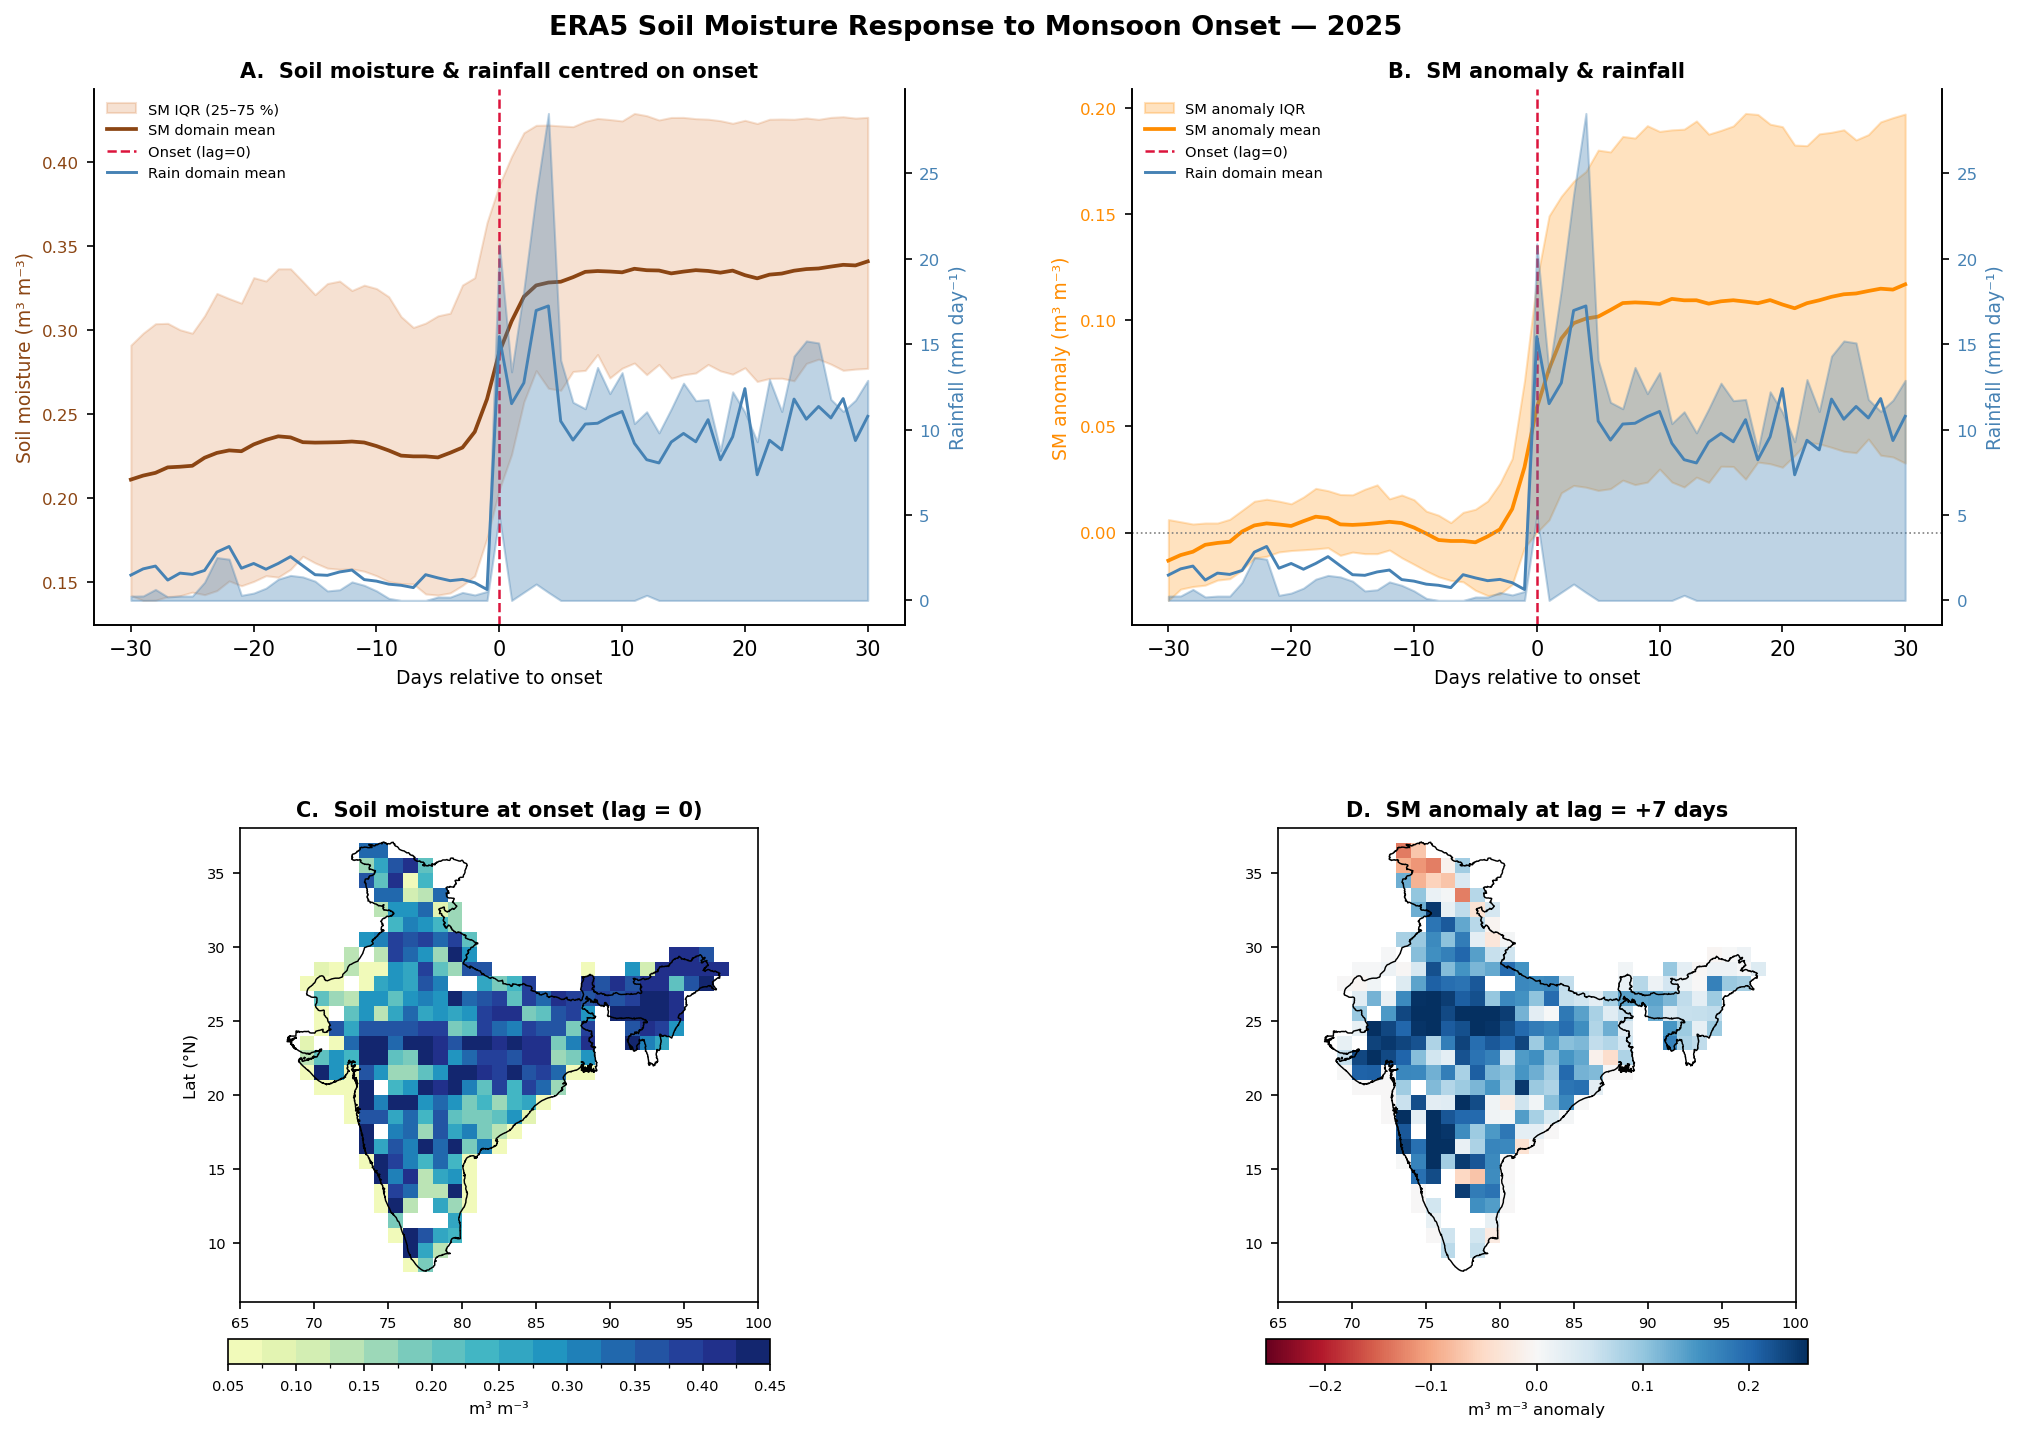

In [13]:
fig = plt.figure(figsize=(14, 10), dpi=150)
gs  = mgridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.28,
                          left=0.08, right=0.96, top=0.93, bottom=0.08)

map_extent = [65, 100, 6, 38]
rain_color = "steelblue"
rain_alpha = 0.35

# ── Panel A: raw SM + rainfall time-series ────────────────────────────────────
axA = fig.add_subplot(gs[0, 0])
axA.fill_between(lags, sm_p25.values, sm_p75.values,
                 color="chocolate", alpha=0.20, label="SM IQR (25–75 %)")
axA.plot(lags, sm_mean.values, color="saddlebrown", linewidth=1.8, label="SM domain mean")
axA.axvline(0, color="crimson", linewidth=1.2, linestyle="--", label="Onset (lag=0)")
axA.set_xlabel("Days relative to onset", fontsize=9)
axA.set_ylabel("Soil moisture (m³ m⁻³)", color="saddlebrown", fontsize=9)
axA.tick_params(axis="y", labelcolor="saddlebrown", labelsize=8)
axA.set_title("A.  Soil moisture & rainfall centred on onset", fontsize=10, fontweight="bold")
for sp in ["top"]: axA.spines[sp].set_visible(False)

axA_r = axA.twinx()
axA_r.fill_between(lags, rain_p25.values, rain_p75.values,
                   color=rain_color, alpha=rain_alpha)
axA_r.plot(lags, rain_mean.values, color=rain_color, linewidth=1.4,
           linestyle="-", label="Rain domain mean")
axA_r.set_ylabel("Rainfall (mm day⁻¹)", color=rain_color, fontsize=9)
axA_r.tick_params(axis="y", labelcolor=rain_color, labelsize=8)
axA_r.spines["top"].set_visible(False)

# Combined legend
h1, l1 = axA.get_legend_handles_labels()
h2, l2 = axA_r.get_legend_handles_labels()
axA.legend(h1 + h2, l1 + l2, fontsize=7, frameon=False, loc="upper left")

# ── Panel B: SM anomaly + rainfall anomaly ────────────────────────────────────
axB = fig.add_subplot(gs[0, 1])
axB.fill_between(lags, anom_p25.values, anom_p75.values,
                 color="darkorange", alpha=0.25, label="SM anomaly IQR")
axB.plot(lags, anom_mean.values, color="darkorange", linewidth=1.8, label="SM anomaly mean")
axB.axvline(0, color="crimson", linewidth=1.2, linestyle="--", label="Onset (lag=0)")
axB.axhline(0, color="gray",    linewidth=0.8, linestyle=":")
axB.set_xlabel("Days relative to onset", fontsize=9)
axB.set_ylabel("SM anomaly (m³ m⁻³)", color="darkorange", fontsize=9)
axB.tick_params(axis="y", labelcolor="darkorange", labelsize=8)
axB.set_title("B.  SM anomaly & rainfall", fontsize=10, fontweight="bold")
for sp in ["top"]: axB.spines[sp].set_visible(False)

axB_r = axB.twinx()
axB_r.fill_between(lags, rain_p25.values, rain_p75.values,
                   color=rain_color, alpha=rain_alpha)
axB_r.plot(lags, rain_mean.values, color=rain_color, linewidth=1.4,
           linestyle="-", label="Rain domain mean")
axB_r.set_ylabel("Rainfall (mm day⁻¹)", color=rain_color, fontsize=9)
axB_r.tick_params(axis="y", labelcolor=rain_color, labelsize=8)
axB_r.spines["top"].set_visible(False)

h1, l1 = axB.get_legend_handles_labels()
h2, l2 = axB_r.get_legend_handles_labels()
axB.legend(h1 + h2, l1 + l2, fontsize=7, frameon=False, loc="upper left")

# ── Shared helper: draw map ───────────────────────────────────────────────────
def _map(ax, data, title, cmap, norm, cbar_label):
    im = ax.pcolormesh(target_lon, target_lat, data,
                       cmap=cmap, norm=norm, shading="nearest", rasterized=True)
    for lons_b, lats_b in get_india_outline(shapefile_path=shp_path):
        ax.plot(lons_b, lats_b, color="black", linewidth=0.7)
    ax.patch.set_visible(False)
    ax.set_xlim(map_extent[0], map_extent[1])
    ax.set_ylim(map_extent[2], map_extent[3])
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Lon (°E)", fontsize=8)
    ax.tick_params(labelsize=7)
    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.07,
                        fraction=0.046, aspect=22)
    cbar.set_label(cbar_label, fontsize=8)
    cbar.ax.tick_params(labelsize=7)

# ── Panel C: SM at onset (lag=0) ─────────────────────────────────────────────
axC = fig.add_subplot(gs[1, 0])
sm_at_onset = sm_centred_da.sel(lag=0).values

sm_bounds = np.linspace(0.05, 0.45, 17)
sm_cmap   = mcolors.ListedColormap(plt.cm.YlGnBu(np.linspace(0.1, 0.95, 16)))
sm_norm   = BoundaryNorm(sm_bounds, 16)

_map(axC, sm_at_onset, "C.  Soil moisture at onset (lag = 0)",
     sm_cmap, sm_norm, "m³ m⁻³")
axC.set_ylabel("Lat (°N)", fontsize=8)

# ── Panel D: SM anomaly at lag = +7 ──────────────────────────────────────────
axD = fig.add_subplot(gs[1, 1])
anom_7 = sm_anom.sel(lag=7).values

anom_max = max(0.06, np.nanpercentile(np.abs(anom_7[np.isfinite(anom_7)]), 95))
anom_cmap   = plt.cm.RdBu
anom_norm   = mcolors.TwoSlopeNorm(vmin=-anom_max, vcenter=0, vmax=anom_max)

_map(axD, anom_7, "D.  SM anomaly at lag = +7 days",
     anom_cmap, anom_norm, "m³ m⁻³ anomaly")

fig.suptitle(f"ERA5 Soil Moisture Response to Monsoon Onset — {YEAR}",
             fontsize=13, fontweight="bold")
plt.savefig(f"../output/sm_onset_summary_{YEAR}.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Single Grid-cell Diagnostic

Inspect the full April–September rainfall + soil moisture time-series at any chosen grid point, with the onset date marked.

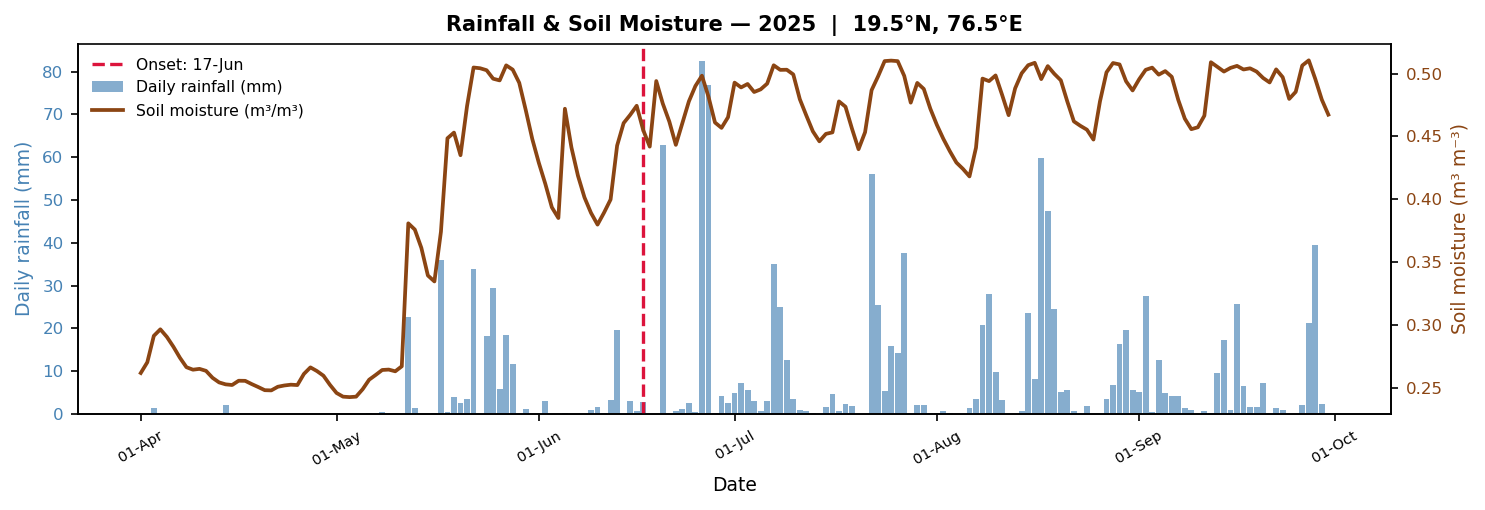

In [11]:
# ── Choose a grid point ──────────────────────────────────────────────────────
SEL_LAT = 19.5
SEL_LON = 76.5

rain_cell  = rainfall_da.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest")
sm_cell    = sm_imd.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest")
onset_cell = onset_da.sel(lat=SEL_LAT, lon=SEL_LON, method="nearest")

actual_lat = float(rain_cell.lat)
actual_lon = float(rain_cell.lon)
onset_ts   = (pd.Timestamp(onset_cell.values)
              if not pd.isna(onset_cell.values) else None)

t0 = pd.Timestamp(f"{YEAR}-04-01")
t1 = pd.Timestamp(f"{YEAR}-09-30")
rain_s = rain_cell.to_series().loc[t0:t1]
sm_s   = sm_cell.to_series().loc[t0:t1]

fig, ax1 = plt.subplots(figsize=(10, 3.5), dpi=150)

# Rainfall on left axis
ax1.bar(rain_s.index, rain_s.values, color="steelblue", width=0.9,
        alpha=0.65, label="Daily rainfall (mm)")
ax1.set_ylabel("Daily rainfall (mm)", color="steelblue", fontsize=9)
ax1.tick_params(axis="y", labelcolor="steelblue", labelsize=8)
ax1.set_xlabel("Date", fontsize=9)

# Soil moisture on right axis
ax2 = ax1.twinx()
ax2.plot(sm_s.index, sm_s.values, color="saddlebrown", linewidth=1.8,
         label="Soil moisture (m³/m³)", zorder=3)
ax2.set_ylabel("Soil moisture (m³ m⁻³)", color="saddlebrown", fontsize=9)
ax2.tick_params(axis="y", labelcolor="saddlebrown", labelsize=8)

# Onset marker
if onset_ts:
    ax1.axvline(onset_ts, color="crimson", linewidth=1.6, linestyle="--",
                zorder=5, label=f"Onset: {onset_ts.strftime('%d-%b')}")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           fontsize=7.5, frameon=False, loc="upper left")

ax1.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d-%b"))
ax1.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator())
ax1.tick_params(axis="x", rotation=30, labelsize=7)
ax1.set_title(f"Rainfall & Soil Moisture — {YEAR}  |  "
              f"{actual_lat:.1f}°N, {actual_lon:.1f}°E",
              fontsize=10, fontweight="bold")

for sp in ["top"]: ax1.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig(f"../output/sm_rainfall_cell_{actual_lat:.1f}N_{actual_lon:.1f}E_{YEAR}.png",
            dpi=150, bbox_inches="tight")
plt.show()
